# Bagging Classification

In [60]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

plt.rcParams["figure.figsize"] = (8,6)
plt.rcParams["figure.dpi"] = 150

In [61]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="Target")

df = pd.concat([X,y],axis=1)

print("Dataset Shape :",df.shape)
print("\n")

display(df.head())

print("\nTarget Classes")
print(data.target_names)

Dataset Shape : (569, 31)




,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0



Target Classes
['malignant' 'benign']


In [62]:
print("="*60)
print("Dataset Information")
print("="*60)

display(df.info())

print("\nMissing Values")

display(df.isnull().sum())

print("\nStatistical Summary")

display(df.describe().T)

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smooth

None


Missing Values


mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
Target                     0
dtype: int64


Statistical Summary


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


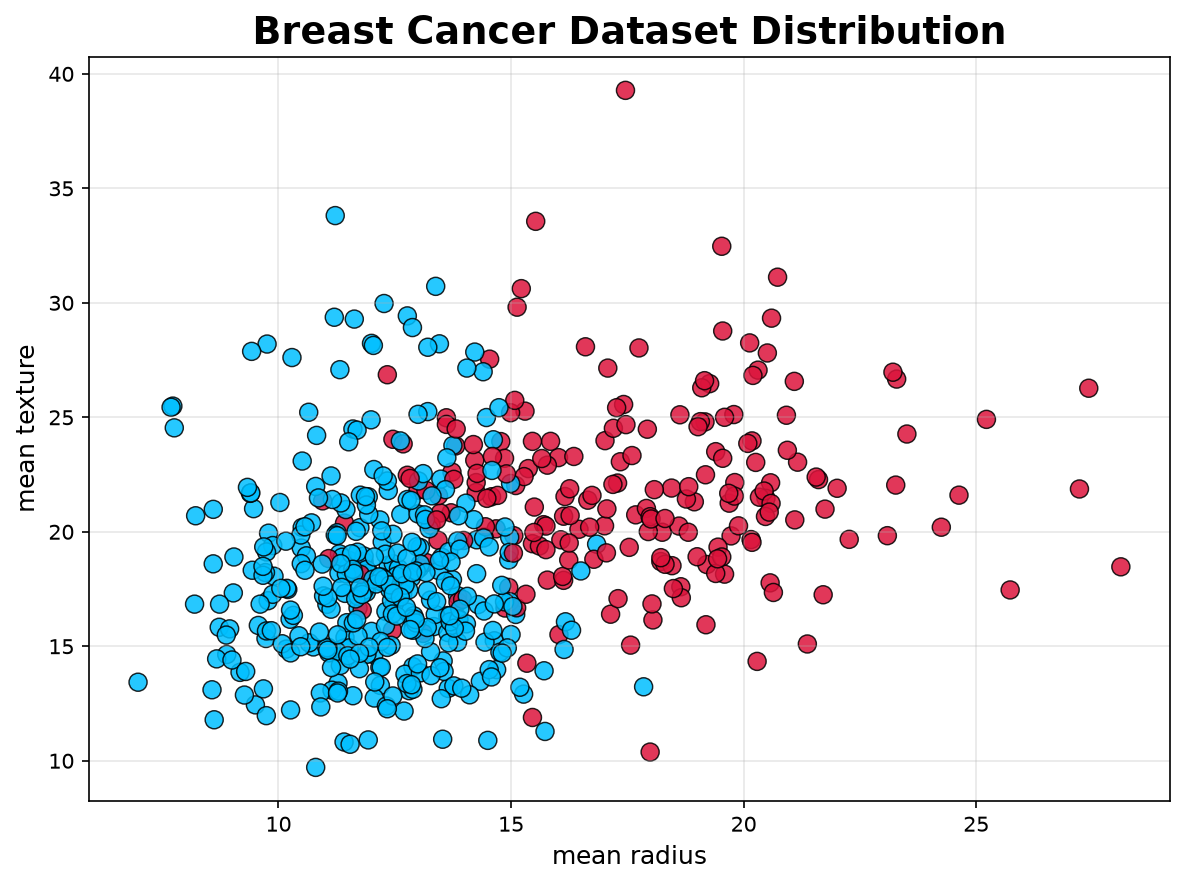

In [63]:
plt.figure(figsize=(8,6))

colors = np.where(y==0,"crimson","deepskyblue")

plt.scatter(
    X.iloc[:,0],
    X.iloc[:,1],
    c=colors,
    s=75,
    edgecolor="black",
    linewidth=0.7,
    alpha=0.85
)

plt.title("Breast Cancer Dataset Distribution",
          fontsize=18,
          fontweight="bold")

plt.xlabel(data.feature_names[0],fontsize=12)
plt.ylabel(data.feature_names[1],fontsize=12)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

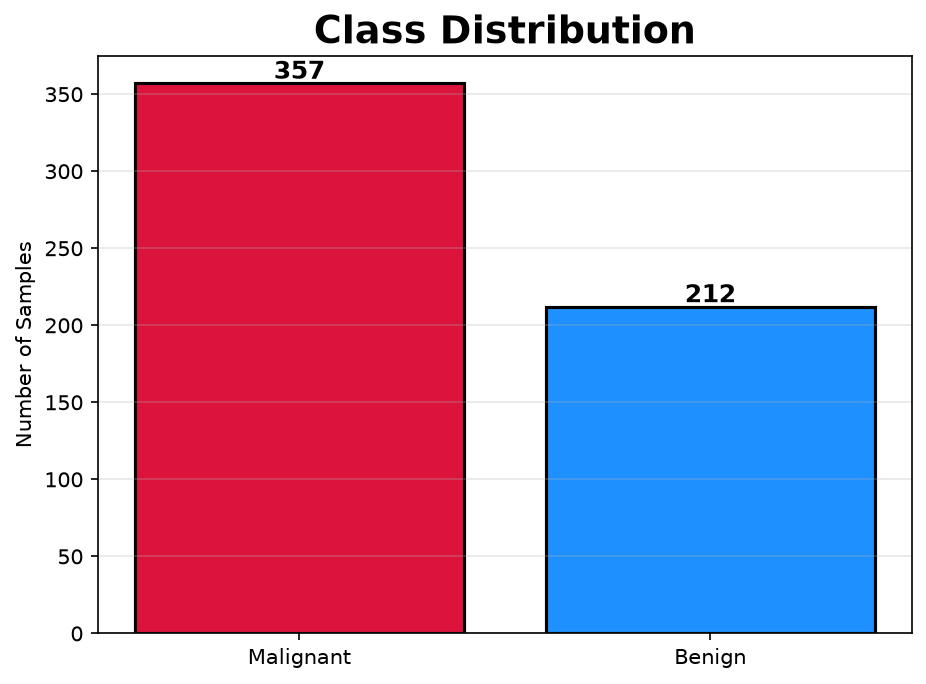

In [64]:
counts = y.value_counts()

plt.figure(figsize=(7,5))

bars = plt.bar(
    ["Malignant","Benign"],
    counts.values,
    color=["crimson","dodgerblue"],
    edgecolor="black",
    linewidth=1.5
)

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+3,
        int(bar.get_height()),
        ha="center",
        fontsize=12,
        fontweight="bold"
    )

plt.title("Class Distribution",
          fontsize=18,
          fontweight="bold")

plt.ylabel("Number of Samples")

plt.grid(axis="y",alpha=0.3)

plt.show()

In [65]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Shape :",X_train.shape)
print("Testing Shape :",X_test.shape)

Training Shape : (455, 30)
Testing Shape : (114, 30)


In [66]:
tree = DecisionTreeClassifier(
    random_state=42
)

tree.fit(X_train,y_train)

tree_pred = tree.predict(X_test)

In [67]:
tree_acc = accuracy_score(y_test,tree_pred)
tree_pre = precision_score(y_test,tree_pred)
tree_rec = recall_score(y_test,tree_pred)
tree_f1 = f1_score(y_test,tree_pred)

print("Decision Tree Performance")
print("-"*35)

print(f"Accuracy  : {tree_acc:.4f}")
print(f"Precision : {tree_pre:.4f}")
print(f"Recall    : {tree_rec:.4f}")
print(f"F1 Score  : {tree_f1:.4f}")

Decision Tree Performance
-----------------------------------
Accuracy  : 0.9123
Precision : 0.9559
Recall    : 0.9028
F1 Score  : 0.9286


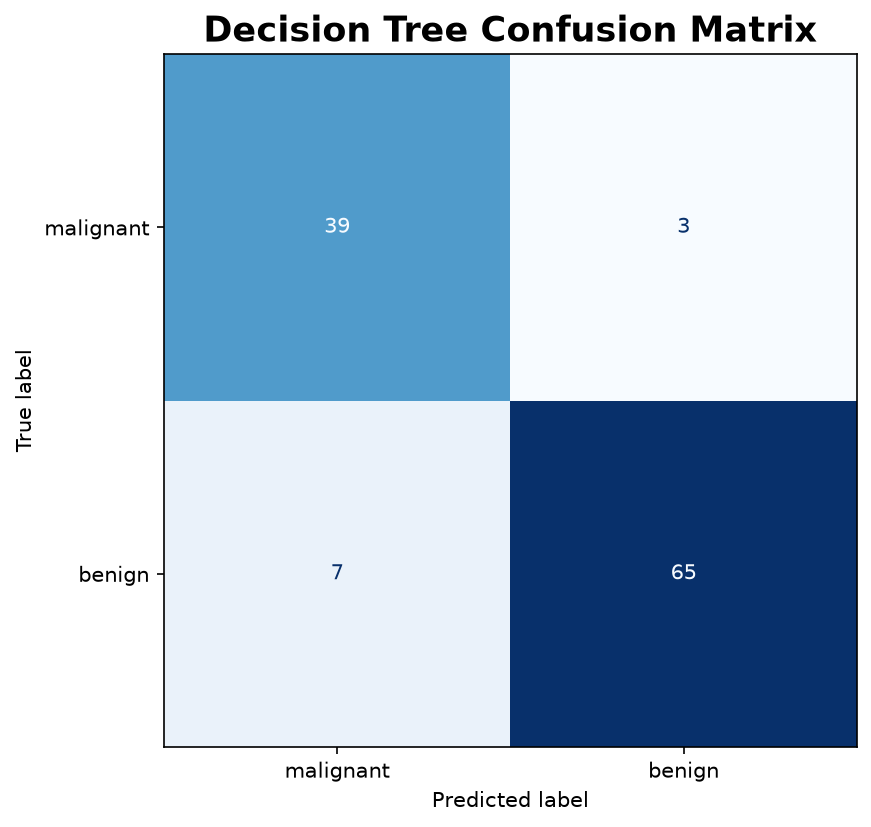

In [68]:
fig,ax = plt.subplots(figsize=(6,6))

disp = ConfusionMatrixDisplay(
    confusion_matrix(y_test,tree_pred),
    display_labels=data.target_names
)

disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=False
)

plt.title("Decision Tree Confusion Matrix",
          fontsize=17,
          fontweight="bold")

plt.show()

In [69]:
bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)

bag.fit(X_train,y_train)

bag_pred = bag.predict(X_test)

In [70]:
bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)

bag.fit(X_train,y_train)

bag_pred = bag.predict(X_test)

In [71]:
bag_acc = accuracy_score(y_test,bag_pred)
bag_pre = precision_score(y_test,bag_pred)
bag_rec = recall_score(y_test,bag_pred)
bag_f1 = f1_score(y_test,bag_pred)

print("Bagging Performance")
print("-"*35)

print(f"Accuracy  : {bag_acc:.4f}")
print(f"Precision : {bag_pre:.4f}")
print(f"Recall    : {bag_rec:.4f}")
print(f"F1 Score  : {bag_f1:.4f}")

print("\nOOB Score :",round(bag.oob_score_,4))

Bagging Performance
-----------------------------------
Accuracy  : 0.9386
Precision : 0.9452
Recall    : 0.9583
F1 Score  : 0.9517

OOB Score : 0.956


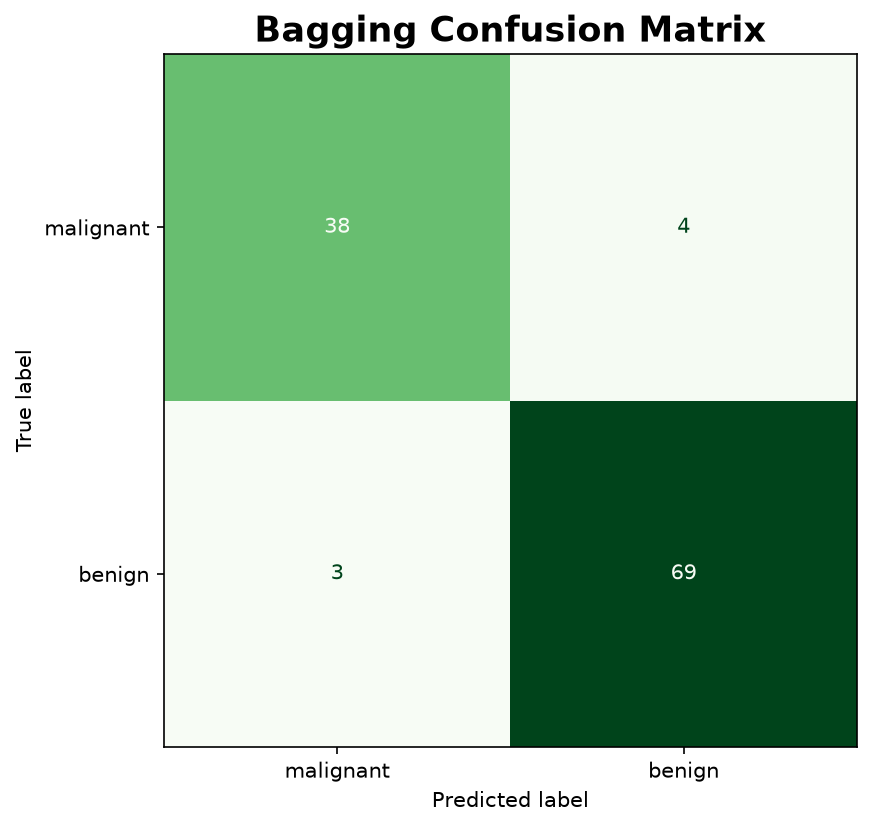

In [72]:
fig,ax = plt.subplots(figsize=(6,6))

disp = ConfusionMatrixDisplay(
    confusion_matrix(y_test,bag_pred),
    display_labels=data.target_names
)

disp.plot(
    cmap="Greens",
    ax=ax,
    colorbar=False
)

plt.title("Bagging Confusion Matrix",
          fontsize=17,
          fontweight="bold")

plt.show()

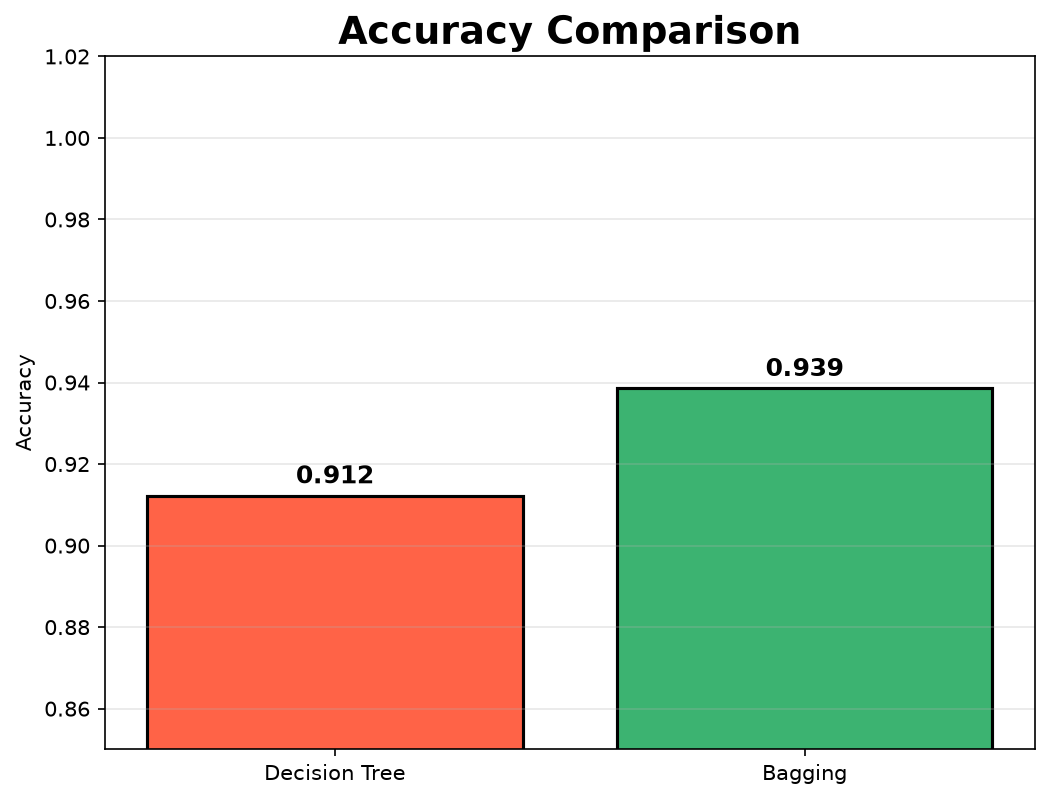

In [73]:
models = ["Decision Tree","Bagging"]

accuracy = [tree_acc,bag_acc]

plt.figure(figsize=(8,6))

bars = plt.bar(
    models,
    accuracy,
    color=["tomato","mediumseagreen"],
    edgecolor="black",
    linewidth=1.5
)

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+0.003,
        f"{bar.get_height():.3f}",
        ha="center",
        fontsize=12,
        fontweight="bold"
    )

plt.ylim(0.85,1.02)

plt.title("Accuracy Comparison",
          fontsize=18,
          fontweight="bold")

plt.ylabel("Accuracy")

plt.grid(axis="y",alpha=0.3)

plt.show()

In [74]:
print("="*60)
print("Decision Tree Report")
print("="*60)

print(classification_report(y_test,tree_pred))

print("="*60)
print("Bagging Report")
print("="*60)

print(classification_report(y_test,bag_pred))

Decision Tree Report
              precision    recall  f1-score   support

           0       0.85      0.93      0.89        42
           1       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114

Bagging Report
              precision    recall  f1-score   support

           0       0.93      0.90      0.92        42
           1       0.95      0.96      0.95        72

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



In [75]:
performance = pd.DataFrame({

    "Model":[
        "Decision Tree",
        "Bagging"
    ],

    "Accuracy":[
        tree_acc,
        bag_acc
    ],

    "Precision":[
        tree_pre,
        bag_pre
    ],

    "Recall":[
        tree_rec,
        bag_rec
    ],

    "F1 Score":[
        tree_f1,
        bag_f1
    ]

})

performance

,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.912281,0.955882,0.902778,0.928571
1,Bagging,0.938596,0.945205,0.958333,0.951724


# Bagging Regression

In [82]:
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import cross_val_score

In [83]:
n_estimators = list(range(1,201,10))

train_accuracy = []
test_accuracy = []
oob_scores = []

for n in n_estimators:

    model = BaggingClassifier(
        estimator=DecisionTreeClassifier(),
        n_estimators=n,
        random_state=42,
        oob_score=True,
        n_jobs=-1
    )

    model.fit(X_train,y_train)

    train_accuracy.append(model.score(X_train,y_train))
    test_accuracy.append(model.score(X_test,y_test))
    oob_scores.append(model.oob_score_)

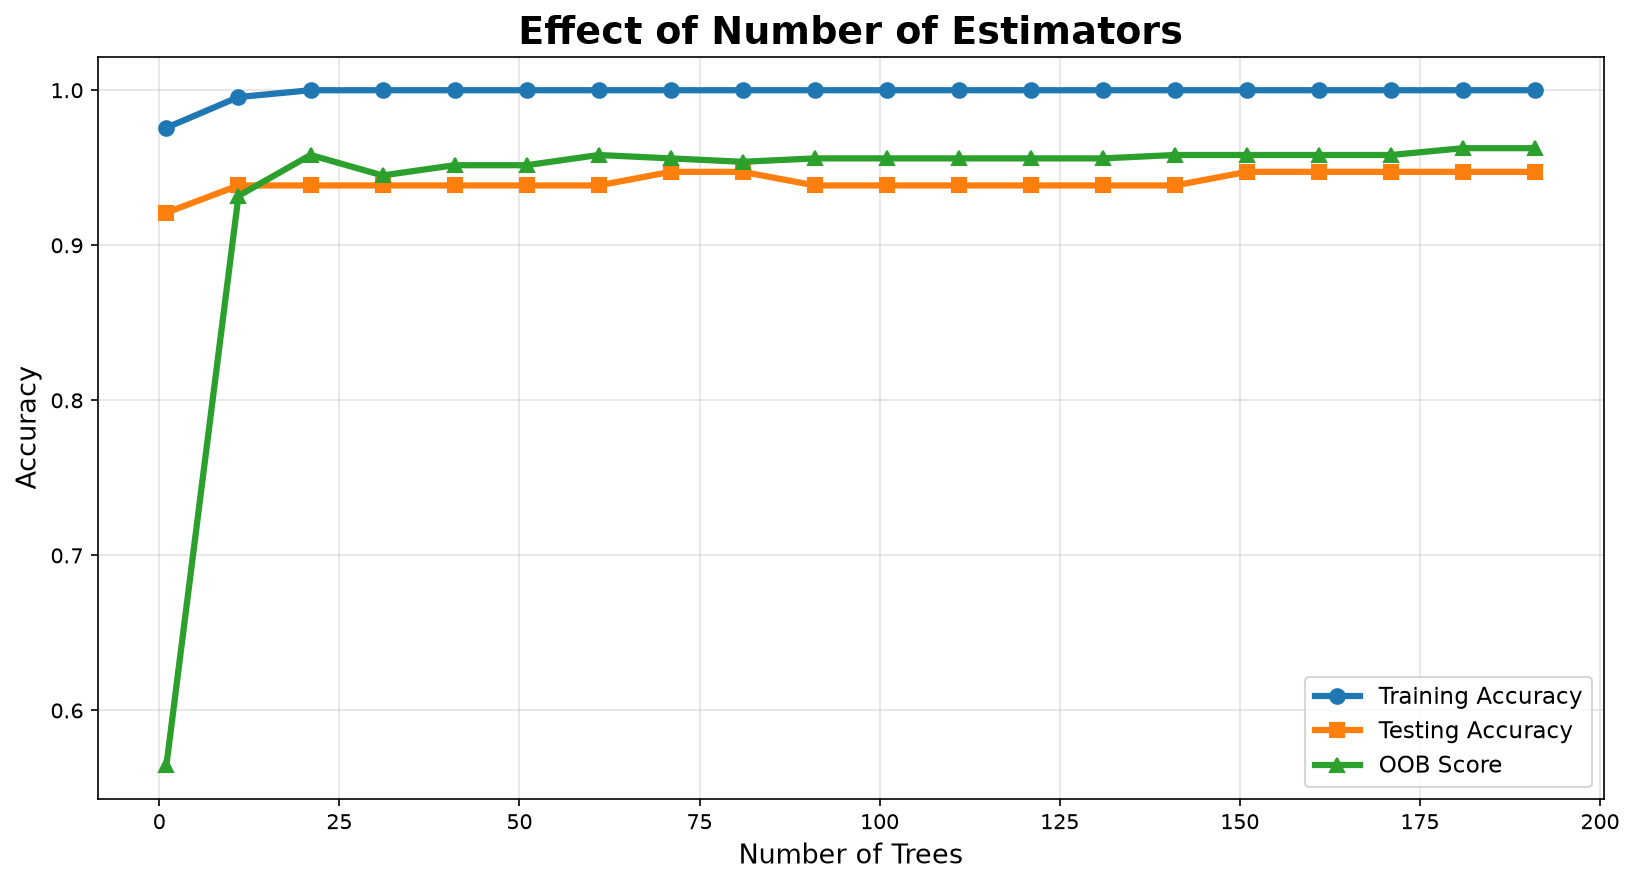

In [84]:
plt.figure(figsize=(11,6),dpi=150)

plt.plot(
    n_estimators,
    train_accuracy,
    marker="o",
    linewidth=3,
    markersize=7,
    label="Training Accuracy"
)

plt.plot(
    n_estimators,
    test_accuracy,
    marker="s",
    linewidth=3,
    markersize=7,
    label="Testing Accuracy"
)

plt.plot(
    n_estimators,
    oob_scores,
    marker="^",
    linewidth=3,
    markersize=7,
    label="OOB Score"
)

plt.title(
    "Effect of Number of Estimators",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Number of Trees",fontsize=13)

plt.ylabel("Accuracy",fontsize=13)

plt.grid(alpha=0.35)

plt.legend(fontsize=11)

plt.tight_layout()

plt.show()

In [85]:
results = pd.DataFrame({

    "Trees":n_estimators,
    "Train Accuracy":train_accuracy,
    "Test Accuracy":test_accuracy,
    "OOB Score":oob_scores

})

display(results)

best_row = results.iloc[results["Test Accuracy"].idxmax()]

print("="*60)
print("Best Model")
print("="*60)

display(best_row)

,Trees,Train Accuracy,Test Accuracy,OOB Score
0,1,0.975824,0.921053,0.564835
1,11,0.995604,0.938596,0.931868
2,21,1.000000,0.938596,0.958242
3,31,1.000000,0.938596,0.945055
4,41,1.000000,0.938596,0.951648
5,51,1.000000,0.938596,0.951648
6,61,1.000000,0.938596,0.958242
7,71,1.000000,0.947368,0.956044
8,81,1.000000,0.947368,0.953846
9,91,1.000000,0.938596,0.956044


Best Model


Trees             71.000000
Train Accuracy     1.000000
Test Accuracy      0.947368
OOB Score          0.956044
Name: 7, dtype: float64

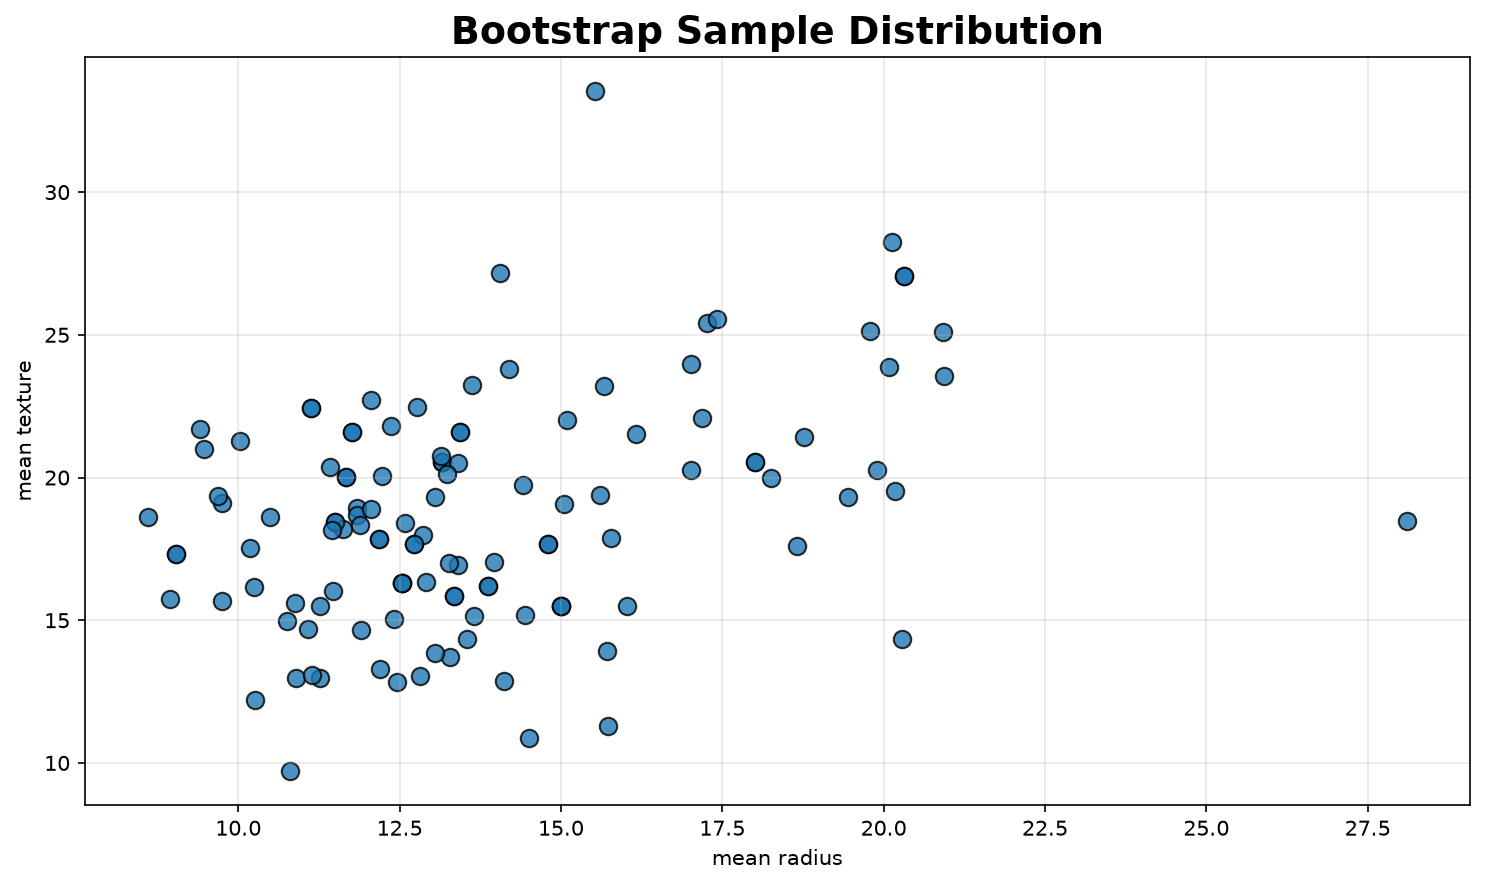

In [86]:
sample = X_train.sample(
    n=120,
    replace=True,
    random_state=42
)

plt.figure(figsize=(10,6),dpi=150)

plt.scatter(

    sample.iloc[:,0],
    sample.iloc[:,1],

    s=70,

    alpha=0.8,

    edgecolor="black"

)

plt.title(

    "Bootstrap Sample Distribution",

    fontsize=18,

    fontweight="bold"

)

plt.xlabel(X.columns[0])

plt.ylabel(X.columns[1])

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

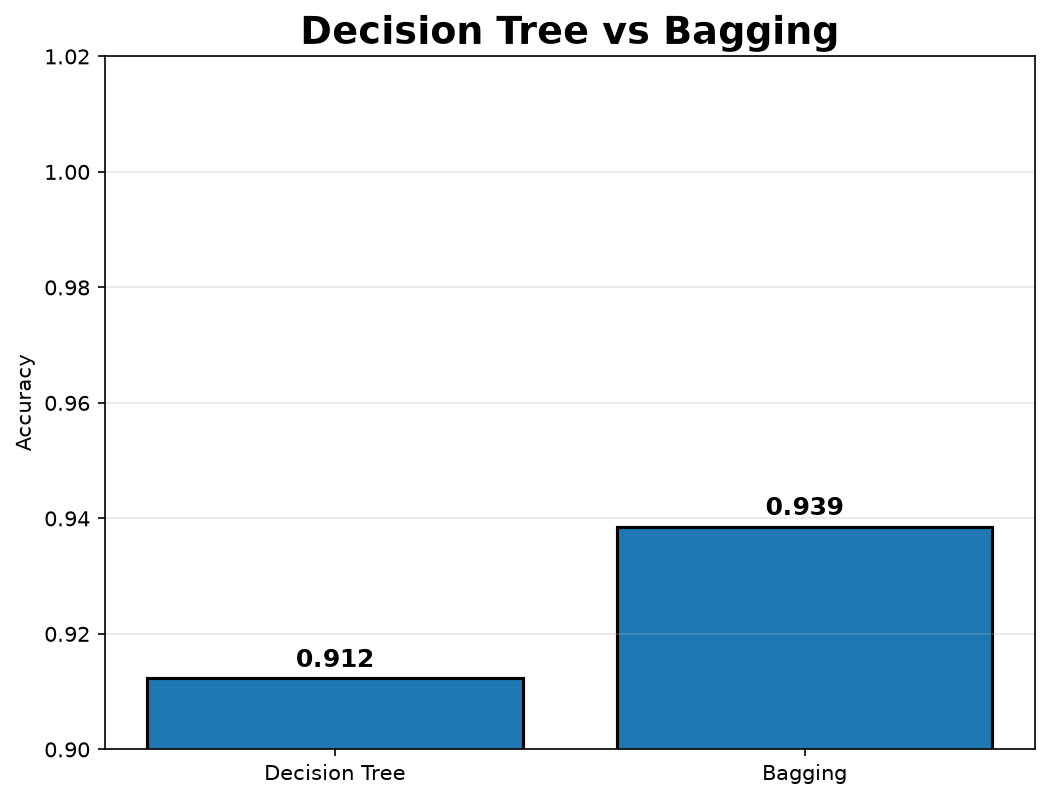

In [87]:
comparison = pd.DataFrame({

    "Model":[
        "Decision Tree",
        "Bagging"
    ],

    "Accuracy":[
        tree_acc,
        bag_acc
    ]

})

plt.figure(figsize=(8,6),dpi=150)

bars = plt.bar(

    comparison["Model"],

    comparison["Accuracy"],

    edgecolor="black",

    linewidth=1.5

)

for bar in bars:

    plt.text(

        bar.get_x()+bar.get_width()/2,

        bar.get_height()+0.002,

        f"{bar.get_height():.3f}",

        ha="center",

        fontsize=12,

        fontweight="bold"

    )

plt.ylim(0.90,1.02)

plt.title(

    "Decision Tree vs Bagging",

    fontsize=18,

    fontweight="bold"

)

plt.ylabel("Accuracy")

plt.grid(axis="y",alpha=0.3)

plt.show()

In [88]:
tree_cv = cross_val_score(

    DecisionTreeClassifier(random_state=42),

    X,

    y,

    cv=5

)

bag_cv = cross_val_score(

    BaggingClassifier(

        estimator=DecisionTreeClassifier(),

        n_estimators=100,

        random_state=42

    ),

    X,

    y,

    cv=5

)

cv = pd.DataFrame({

    "Model":[
        "Decision Tree",
        "Bagging"
    ],

    "Average CV Accuracy":[

        tree_cv.mean(),

        bag_cv.mean()

    ]

})

display(cv)

,Model,Average CV Accuracy
0,Decision Tree,0.917342
1,Bagging,0.957895


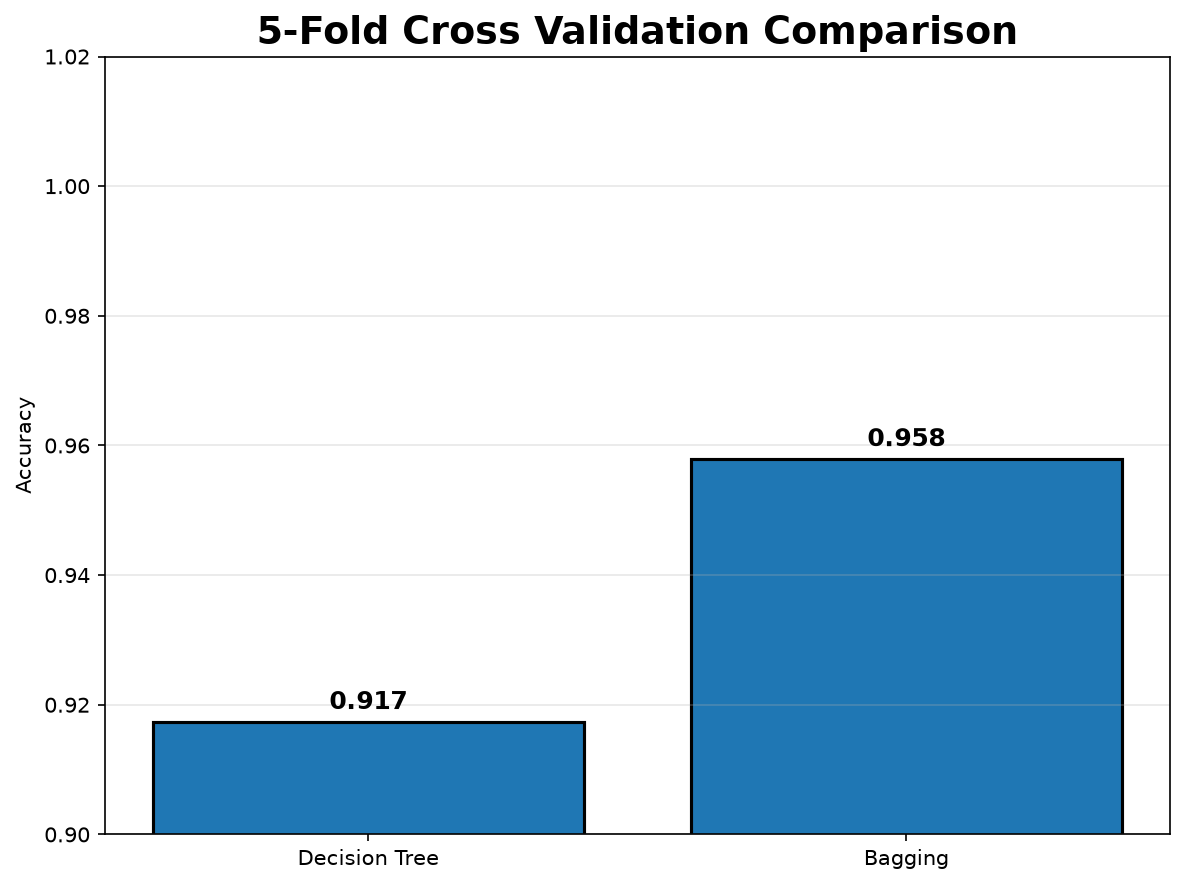

In [89]:
plt.figure(figsize=(8,6),dpi=150)

bars = plt.bar(

    cv["Model"],

    cv["Average CV Accuracy"],

    edgecolor="black",

    linewidth=1.5

)

for bar in bars:

    plt.text(

        bar.get_x()+bar.get_width()/2,

        bar.get_height()+0.002,

        f"{bar.get_height():.3f}",

        ha="center",

        fontsize=12,

        fontweight="bold"

    )

plt.ylim(0.90,1.02)

plt.title(

    "5-Fold Cross Validation Comparison",

    fontsize=18,

    fontweight="bold"

)

plt.ylabel("Accuracy")

plt.grid(axis="y",alpha=0.3)

plt.tight_layout()

plt.show()

In [90]:
summary = pd.DataFrame({

    "Metric":[

        "Decision Tree Accuracy",

        "Bagging Accuracy",

        "Decision Tree CV",

        "Bagging CV",

        "OOB Score"

    ],

    "Value":[

        round(tree_acc,4),

        round(bag_acc,4),

        round(tree_cv.mean(),4),

        round(bag_cv.mean(),4),

        round(bag.oob_score_,4)

    ]

})

display(summary)

,Metric,Value
0,Decision Tree Accuracy,0.9123
1,Bagging Accuracy,0.9386
2,Decision Tree CV,0.9173
3,Bagging CV,0.9579
4,OOB Score,0.9560
